import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

memanggil dataset

In [3]:
dataset = pd.read_csv('silver_prices_data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

Grafik data

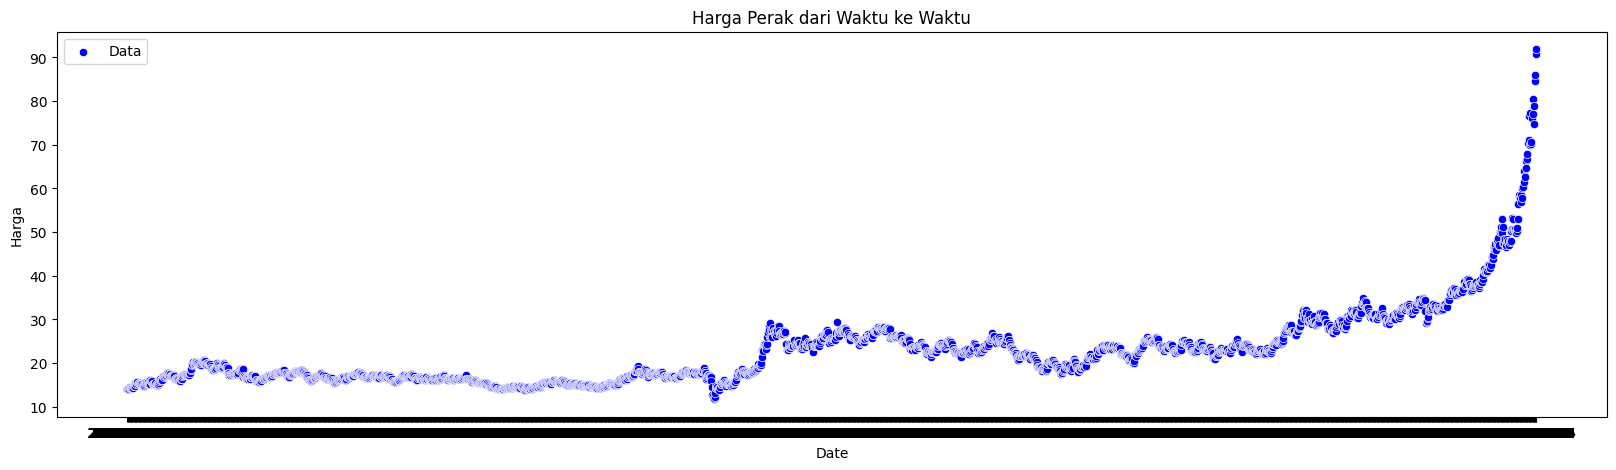

In [4]:
plt.figure(figsize=(20, 5))

sns.scatterplot(
    x=dataset["Date"], 
    y=dataset["Price"],
    color="blue", 
    label="Data"
)

plt.xlabel("Date")
plt.ylabel("Harga")
plt.title("Harga Perak dari Waktu ke Waktu")

plt.legend()
plt.show()

memecah data 

In [ ]:
# Variabel independen (X) = Tahun
X = pd.DataFrame(X[:, 0], columns=['Date'])

# Variabel dependen (Y) = Total
Y = y

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

NameError: name 'dataset' is not defined

Regresi linear

In [4]:
# Convert Date to numeric (days since epoch)
X_train_numeric = pd.to_datetime(X_train['Date']).astype(int) // 10**9
X_test_numeric = pd.to_datetime(X_test['Date']).astype(int) // 10**9

model = LinearRegression()
model.fit(X_train_numeric.values.reshape(-1, 1), Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Prediksi

In [34]:
Y_pred = model.predict(X_test_numeric.values.reshape(-1, 1))

evaluasi model

In [36]:
Y_pred = model.predict(X_test_numeric.values.reshape(-1, 1))

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-Squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 3.68
Mean Squared Error (MSE): 25.70
R-Squared (R2): 0.55


visual prediksi

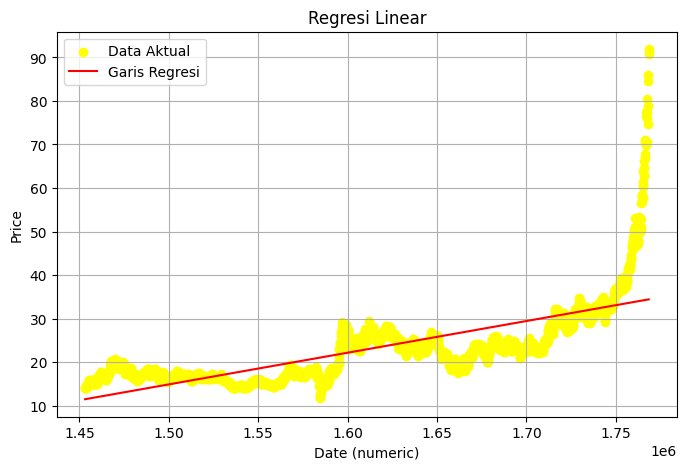

In [38]:
plt.figure(figsize=(8, 5))

# Convert Date to numeric for plotting
X_numeric_all = pd.to_datetime(X['Date']).astype(int) // 10**9

# Scatter semua data (bukan cuma test)
plt.scatter(X_numeric_all, Y, color='yellow', label="Data Aktual")

# Garis regresi (pakai seluruh data, dan urutkan)
X_sorted_idx = X_numeric_all.argsort()
X_sorted_numeric = X_numeric_all.iloc[X_sorted_idx].values.reshape(-1, 1)
Y_pred_full = model.predict(X_sorted_numeric)

plt.plot(X_sorted_numeric, Y_pred_full, color='red', label="Garis Regresi")

plt.xlabel("Date (numeric)")
plt.ylabel("Price")
plt.title("Regresi Linear")

plt.legend()
plt.grid(True)
plt.show()

Tabel prediksi

In [47]:

# Create future dates for prediction (2026-2030)
future_dates = pd.DataFrame({
    "Date": pd.date_range(start='2027-01-01', end='2030-12-31', freq='YS')
})

# Convert dates to numeric format (same as training data)
future_dates_numeric = pd.to_datetime(future_dates['Date']).astype(int) // 10**9

# Make predictions
prediksi_full = model.predict(future_dates_numeric.values.reshape(-1, 1))

# Create results dataframe
hasil_prediksi = pd.DataFrame({
    "Tahun": future_dates['Date'].dt.year,
    "Prediksi Harga": prediksi_full,
})

print("\n===== PREDIKSI MASA DEPAN =====")
print(hasil_prediksi.round(2).to_string(index=False))


===== PREDIKSI MASA DEPAN =====
 Tahun  Prediksi Harga
  2027           36.63
  2028           38.92
  2029           41.22
  2030           43.52


In [5]:
import pickle

# Simpan model ke file .pkl
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model berhasil disimpan sebagai model.pkl")

Model berhasil disimpan sebagai model.pkl
